<span style="color:darkblue"> <font size="5"> 
Assignment 2 

Zepeng Zhou


For this assignment you will using the Formula 1 dataset introduced in Lecture 3 in the Github 
notes. Formula 1 is an international car racing competition, where drivers from all over the 
world compete for a title, and where individual races take place across different countries. Each 
driver is part of a team called a “Constructor”, typically sponsored by a specific car 
manufacturer. You can find more information about the sport and the dataset here:

https://en.wikipedia.org/wiki/Formula_One

https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020

Use the datasets to answer the following questions:

a) Which three constructors had the highest number of total points between 1981 and 
2020? How many total points did each of them get? How do the total number of points 
for each constructor compare to the average across constructors?

b) Which three constructors had the highest number of total points between 2001 and 
2020? How many total points did each of them get? How do the total number of points 
for each constructor compare to the average across constructors?

c) How did the rankings change across the two time periods?

d) How many different drivers did Ferrari have between 1981 and 2020?

e) What was the best year for Ferrari between 1981 and 2020?

For this assignment you will be expected for merge multiple datasets (for instance names and 
points may be on different datasets), check for missing values, practice chaining operations, 
and create appropriate visualizations.
- Start by checking the codebook to figure out which information table contains the 
relevant information.
- You can come to office hours if you have any questions.

 <font size="5"> 
1. Import libraries and data

According to the assignment requirements, this analysis needs to use four datasets: 

constructors, drivers, races, and results. 

Therefore, I imported these four datasets.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
constructors = pd.read_csv("data_raw/constructors.csv")
drivers = pd.read_csv("data_raw/drivers.csv")
races = pd.read_csv("data_raw/races.csv")
results = pd.read_csv("data_raw/results.csv")

In [27]:
print(constructors.head())
print(drivers.head())
print(races.head())
print(results.head())

   constructorId constructorRef        name nationality  \
0              1        mclaren     McLaren     British   
1              2     bmw_sauber  BMW Sauber      German   
2              3       williams    Williams     British   
3              4        renault     Renault      French   
4              5     toro_rosso  Toro Rosso     Italian   

                                                 url  
0               http://en.wikipedia.org/wiki/McLaren  
1            http://en.wikipedia.org/wiki/BMW_Sauber  
2  http://en.wikipedia.org/wiki/Williams_Grand_Pr...  
3  http://en.wikipedia.org/wiki/Renault_in_Formul...  
4   http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso  
   driverId   driverRef number code  forename     surname         dob  \
0         1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg      6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso


I noticed that both the constructor and race datasets contain a variable named name, 

but they refer to different contents. So, I renamed these two variables separately.

In [28]:
# specify race_name and constructor_name

dict_rename_races = {"name": "race_name"}
races = races.rename(columns = dict_rename_races)

dict_rename_constructors = {"name": "constructor_name"}
constructors = constructors.rename(columns = dict_rename_constructors)

 <font size="5"> 
2. Data cleaning

After browsing and familiarizing myself with the four datasets, 

I first used the dtypes function to check the variable types in each dataset.

In [29]:
# Check the data types of each dataset
print("Constructors columns and dtypes:")
print(constructors.dtypes)
print("\nDrivers columns and dtypes:")
print(drivers.dtypes)
print("\nRaces columns and dtypes:")
print(races.dtypes)
print("\nResults columns and dtypes:")
print(results.dtypes)

Constructors columns and dtypes:
constructorId        int64
constructorRef      object
constructor_name    object
nationality         object
url                 object
dtype: object

Drivers columns and dtypes:
driverId        int64
driverRef      object
number         object
code           object
forename       object
surname        object
dob            object
nationality    object
url            object
dtype: object

Races columns and dtypes:
raceId          int64
year            int64
round           int64
circuitId       int64
race_name      object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object

Results columns and dtypes:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
num

I then used the pd.unique function to check the uniqueness of constructor, driver, and race, 

and by comparing the total number of rows with the number of unique rows in each dataset, 

I ensured that there were no duplicate observations.

In [30]:
# check the uniqueness of primary keys

unique_constructorId = pd.unique(constructors['constructorId'])
unique_driverId = pd.unique(drivers['driverId'])
unique_raceId = pd.unique(races['raceId'])

print("\nCheck constructorId uniqueness:",
      len(unique_constructorId) == len(constructors))
print("Check driverId uniqueness:",
      len(unique_driverId) == len(drivers))
print("Check raceId uniqueness:",
      len(unique_raceId) == len(races))



Check constructorId uniqueness: True
Check driverId uniqueness: True
Check raceId uniqueness: True


I used the describe() function to check whether there were any missing values in the results dataset.

In [31]:
# check the quality of results data

print("Results describe:")
print(results.describe())

Results describe:
           resultId        raceId      driverId  constructorId          grid  \
count  25840.000000  25840.000000  25840.000000   25840.000000  25840.000000   
mean   12921.334327    531.425813    261.732082      48.628328     11.179063   
std     7460.682031    299.440908    268.623016      59.732131      7.243725   
min        1.000000      1.000000      1.000000       1.000000      0.000000   
25%     6460.750000    293.000000     56.000000       6.000000      5.000000   
50%    12920.500000    514.000000    163.000000      25.000000     11.000000   
75%    19380.250000    784.000000    360.000000      58.000000     17.000000   
max    25845.000000   1096.000000    856.000000     214.000000     34.000000   

       positionOrder        points          laps      statusId  
count   25840.000000  25840.000000  25840.000000  25840.000000  
mean       12.876006      1.877053     45.977515     17.568692  
std         7.712391      4.169849     29.808951     26.155476  
m

Since the assignment only requires analyzing race data from 1981 to 2020, 

I filtered the race dataset to include only these years.

In [39]:
# filter races between 1981 and 2020

races_new = races.query("year >= 1981 & year <= 2020")
races_new.to_csv("data_clean/races_new.csv", index=False)


 <font size="5"> 
3. Merging data

I created a chain to merge the four datasets and selected the variables required for this assignment, resulting in a concise dataset.

In [62]:
full_data = (
    pd.merge(results, races_new, on="raceId")
      .merge(constructors, on="constructorId")
      .merge(drivers, on="driverId")
)

simple_data = full_data[["year", "constructorRef", "driverId", "surname", "points"]]
simple_data.to_csv("data_clean/simple_data.csv", index=False)

simple_data.info()
simple_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16650 entries, 0 to 16649
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            16650 non-null  int64  
 1   constructorRef  16650 non-null  object 
 2   driverId        16650 non-null  int64  
 3   surname         16650 non-null  object 
 4   points          16650 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 650.5+ KB


,year,driverId,points
count,16650.000000,16650.000000,16650.000000
mean,1999.923183,191.275075,2.141742
std,11.719264,274.230898,4.566264
min,1981.000000,1.000000,0.000000
25%,1990.000000,23.000000,0.000000
50%,1999.000000,90.500000,0.000000
75%,2011.000000,160.000000,2.000000
max,2020.000000,851.000000,50.000000


 <font size="5"> 
4. Top 3 constructors between 1981-2020 - Question a)

a) Which three constructors had the highest number of total points between 1981 and 
2020? 

- ferrari, mercedes, and mclaren

How many total points did each of them get? 

- ferrari: 7374

- mercedes: 5685

- mclaren: 5229.5

How do the total number of points for each constructor compare to the average across constructors?

- They are all way higher than the average. Please see the figure below.

In [ ]:
# Group by constructorRef and calculate the total points for each team
# Sort the points from highest to lowest and select the top 3
# Calculate the average points of all teams

points_81_20 = simple_data.groupby("constructorRef")["points"].sum()

top3_81_20 = points_81_20.sort_values(ascending=False).head(3)

avg_81_20 = points_81_20.mean()

print("1981–2020 Top 3 Constructors:")
print(top3_81_20)
print("\nAverage points across constructors:", avg_81_20)

1981–2020 Top 3 Constructors:
constructorRef
ferrari     7374.0
mercedes    5685.0
mclaren     5229.5
Name: points, dtype: float64

Average points across constructors: 532.2388059701492


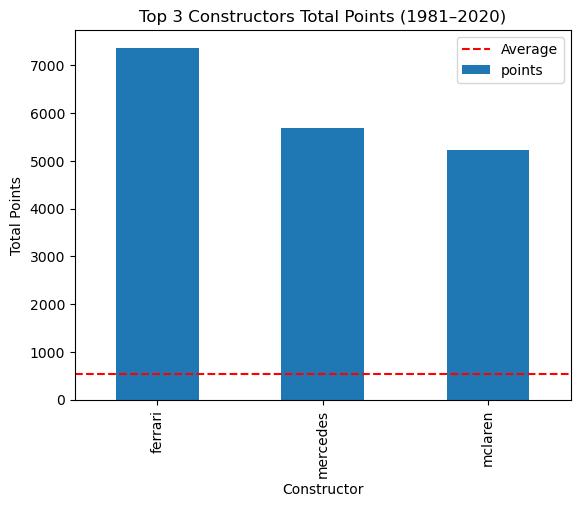

In [42]:
# Visualize top3 constructors' points

top3_81_20.plot(kind="bar")

plt.axhline(y=avg_81_20, color="red", linestyle="--", label="Average")

plt.title("Top 3 Constructors Total Points (1981–2020)")
plt.xlabel("Constructor")
plt.ylabel("Total Points")
plt.legend()

plt.show()

 <font size="5"> 
5. Top 3 constructors between 2001-2020 - Question b)

b) Which three constructors had the highest number of total points between 2001 and 2020? 

- farrari, mercedes, and red_bull

How many total points did each of them get? 

- farrari: 5862

- mercedes: 5685

- red_bull: 5043.5

How do the total number of points for each constructor compare to the average across constructors?

- They are way higher than the average. Please see the figure below.

In [ ]:
# Group by constructorRef and calculate the total points for each team
# Sort the points from highest to lowest and select the top 3
# Calculate the average points of all teams during this time period

data_01_20 = simple_data.query("year >= 2001")

points_01_20 = data_01_20.groupby("constructorRef")["points"].sum()
top3_01_20 = points_01_20.sort_values(ascending=False).head(3)
avg_01_20 = points_01_20.mean()

print("2001–2020 Top 3 Constructors:")
print(top3_01_20)
print("\nAverage points across constructors:", avg_01_20)

2001–2020 Top 3 Constructors:
constructorRef
ferrari     5862.0
mercedes    5685.0
red_bull    5043.5
Name: points, dtype: float64

Average points across constructors: 786.0142857142857


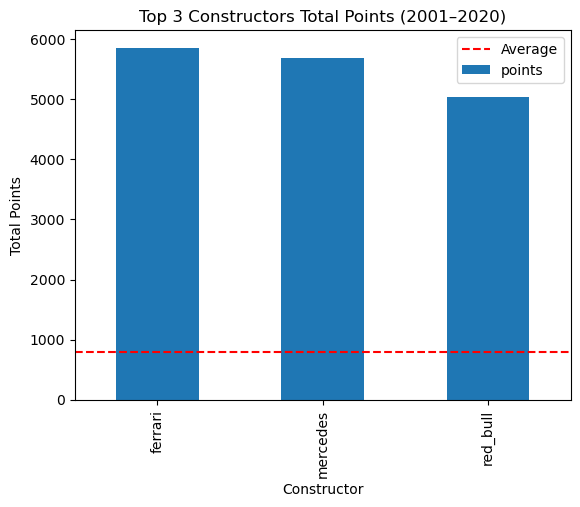

In [ ]:
# Visualize the results

top3_01_20.plot(kind="bar")

plt.axhline(y=avg_01_20, color="red", linestyle="--", label="Average")

plt.title("Top 3 Constructors Total Points (2001–2020)")
plt.xlabel("Constructor")
plt.ylabel("Total Points")
plt.legend()

plt.show()

 <font size="5"> 
6. Comparison between two time periods - Question c)

c) How did the rankings change across the two time periods?

- The veteran powerhouse Ferrari has consistently held the top position, but its lead has narrowed in the 21st century. 

- Mercedes and Red Bull have risen rapidly in the 21st century, becoming Ferrari’s main rivals. 

- Traditional strong teams such as McLaren and Williams have experienced a significant decline or even disappeared in 21st century.

- Rmerging teams like Force India, Toro Rosso, Haas, and Toyota have entered the stage in the 21st century, replacing some of the older teams.


In [47]:
# The rankings of total points across all constructors between 1981-2020

points_81_20 = simple_data.groupby("constructorRef")["points"].sum()
rank_81_20 = points_81_20.sort_values(ascending=False).reset_index()
rank_81_20["Rank_81_20"] = range(1, len(rank_81_20)+1)


In [48]:
# The rankings of total points across all constructors between 2001-2020

points_01_20 = simple_data.query("year >= 2001").groupby("constructorRef")["points"].sum()
rank_01_20 = points_01_20.sort_values(ascending=False).reset_index()
rank_01_20["Rank_01_20"] = range(1, len(rank_01_20)+1)

In [ ]:
# Compare the two rankings

rank_compare = pd.merge(rank_81_20[["constructorRef","Rank_81_20"]],
                        rank_01_20[["constructorRef","Rank_01_20"]],
                        on="constructorRef",
                        how="outer")

print(rank_compare)

   constructorRef  Rank_81_20  Rank_01_20
0             ags          45         NaN
1            alfa          24        19.0
2      alphatauri          25        17.0
3          arrows          23        26.0
4             ats          42         NaN
..            ...         ...         ...
62         toyota          16        13.0
63        tyrrell          22         NaN
64         virgin          54        35.0
65       williams           5         5.0
66       zakspeed          46         NaN

[67 rows x 3 columns]


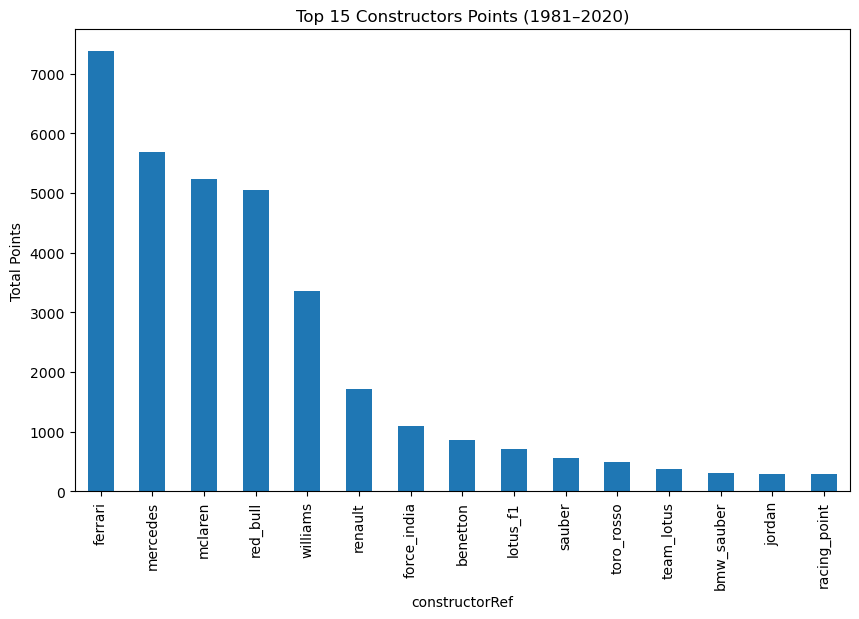

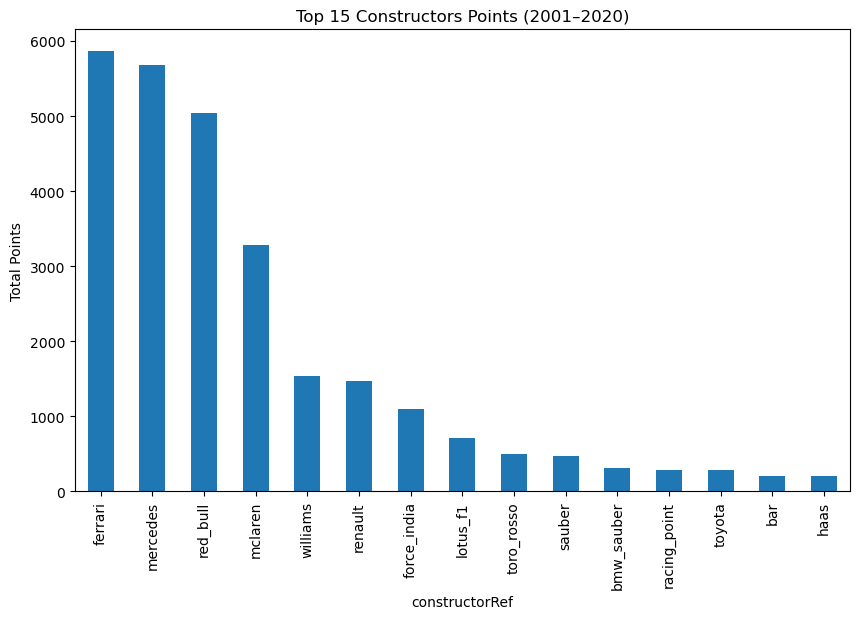

In [ ]:
# Visualization: I chose to compare the top 15 constructors in each time period due to the limited space on the graph.

# 1981–2020 Top 15
rank_81_20.set_index("constructorRef")["points"].head(15).plot(kind="bar", figsize=(10,6))
plt.title("Top 15 Constructors Points (1981–2020)")
plt.ylabel("Total Points")
plt.show()

# 2001–2020 Top 15
rank_01_20.set_index("constructorRef")["points"].head(15).plot(kind="bar", figsize=(10,6))
plt.title("Top 15 Constructors Points (2001–2020)")
plt.ylabel("Total Points")
plt.show()


 <font size="5"> 
7. Drives of Ferrari between 1981-2020 - Question d)

d) How many different drivers did Ferrari have between 1981 and 2020?

- 25

In [ ]:
# Used the len function to calculate the number of unique Ferrari drivers between 1981 and 2020

ferrari_drivers = simple_data.query("constructorRef == 'ferrari'")
num_drivers = len(ferrari_drivers["driverId"].unique())

print("Number of different Ferrari drivers (1981–2020):", num_drivers)

Number of different Ferrari drivers (1981–2020): 25


 <font size="5"> 
8. Best year for Ferrari - Question e)

e) What was the best year for Ferrari between 1981 and 2020?

- 2018

In [ ]:
# Calculate total points for Ferrari each year between 1981 and 2020
# The head(1) should be the best year when the results are sorted in descending order

ferrari_points_by_year = ferrari_drivers.groupby("year")["points"].sum()
best_year = ferrari_points_by_year.sort_values(ascending=False).head(1)

print("Best year for Ferrari (1981–2020):")
print(best_year)

Best year for Ferrari (1981–2020):
year
2018    571.0
Name: points, dtype: float64


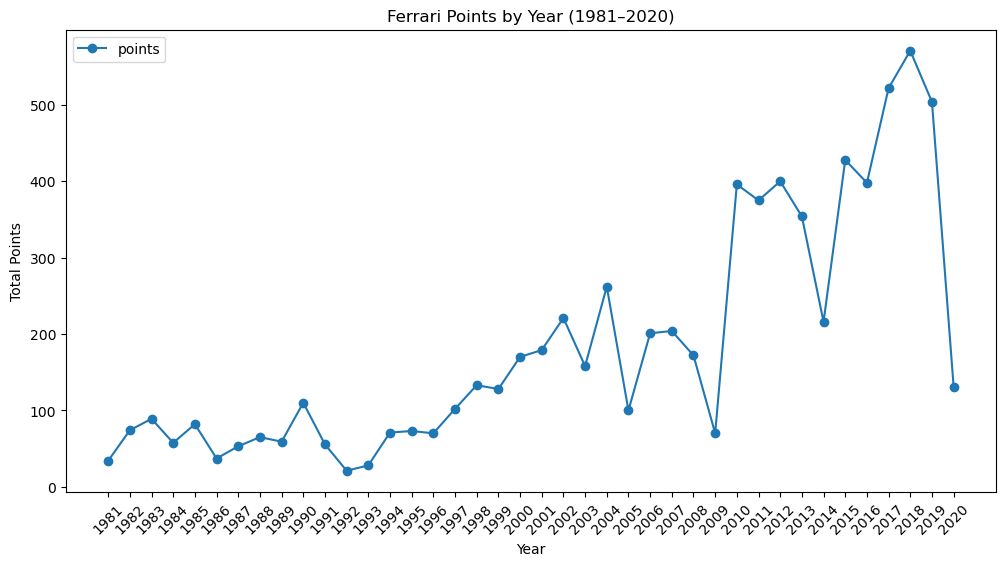

In [ ]:
# Visualize the results

ferrari_points_by_year.plot(kind="line", marker="o", figsize=(12,6))

plt.title("Ferrari Points by Year (1981–2020)")
plt.xlabel("Year")
plt.ylabel("Total Points")
plt.xticks(ferrari_points_by_year.index, rotation=45)
plt.legend()
plt.show()
